In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original, raw dataset to analyze true distributions
df = pd.read_csv('Titanic-Dataset.csv') 

print("Environment ready! Raw dataset loaded successfully.")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

Environment ready! Raw dataset loaded successfully.
Dataset Dimensions: 891 rows, 12 columns


In [2]:
print("=== 1. Statistical Spread of Numerical Features ===")
display(df.describe())

print("\n=== 2. Frequency Summary of Categorical Features ===")
display(df.describe(include=['O']))

print("\n=== 3. Missing Data Structural Gaps (Percentage) ===")
missing_percentages = (df.isnull().sum() / len(df)) * 100
display(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

=== 1. Statistical Spread of Numerical Features ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== 2. Frequency Summary of Categorical Features ===


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644



=== 3. Missing Data Structural Gaps (Percentage) ===


Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64

C:\Users\Anubhav\AppData\Local\Temp\ipykernel_16400\478703422.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_only.index, y=missing_only.values, palette='Reds_r', ax=axes[1])


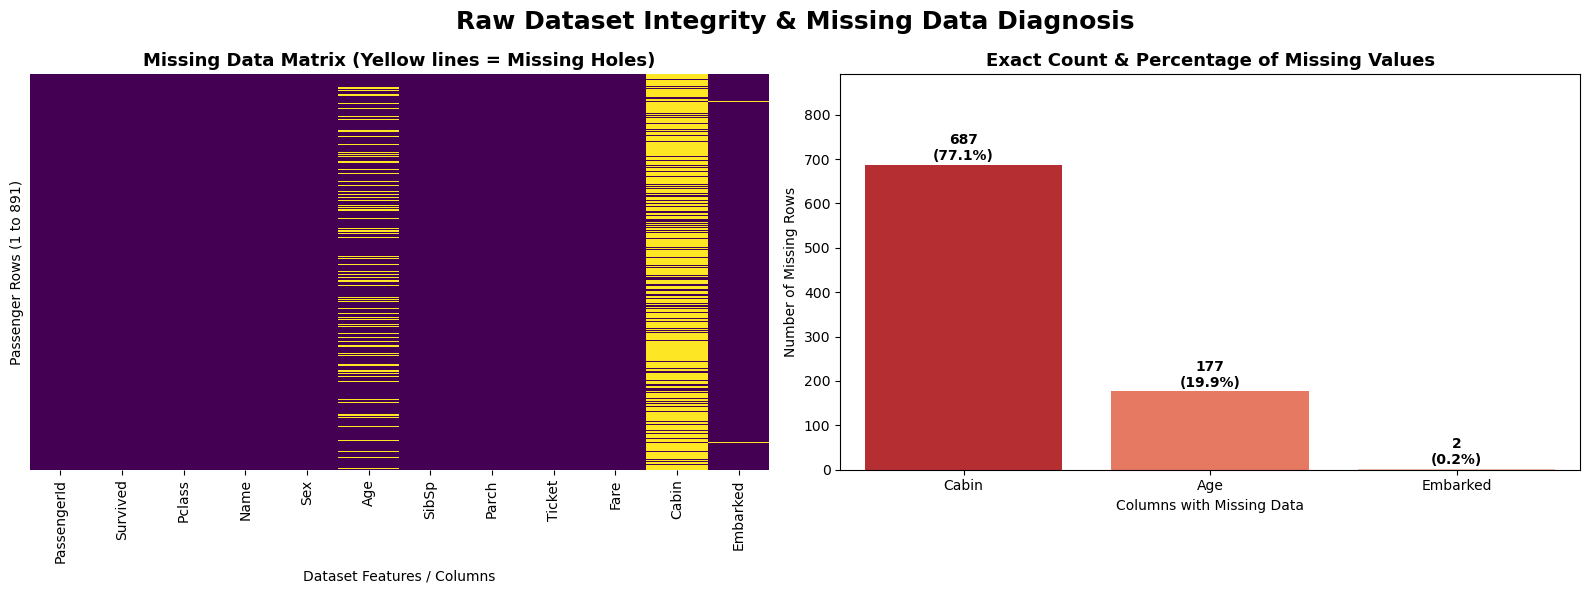

In [3]:
# 1x2 layout for raw data diagnostics
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
fig.suptitle('Raw Dataset Integrity & Missing Data Diagnosis', fontsize=18, fontweight='bold')

# Plot 1: Visual Map of Missing Values (Heatmap)
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Data Matrix (Yellow lines = Missing Holes)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dataset Features / Columns')
axes[0].set_ylabel('Passenger Rows (1 to 891)')

# Plot 2: Exact Missing Count Breakdown (Bar Chart)
missing_counts = df.isnull().sum()
missing_only = missing_counts[missing_counts > 0].sort_values(ascending=False)

if not missing_only.empty:
    sns.barplot(x=missing_only.index, y=missing_only.values, palette='Reds_r', ax=axes[1])
    for i, val in enumerate(missing_only.values):
        axes[1].text(i, val + 10, f"{val}\n({(val/len(df))*100:.1f}%)", ha='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No Missing Values Found!', ha='center', va='center', fontsize=14)

axes[1].set_title('Exact Count & Percentage of Missing Values', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Columns with Missing Data')
axes[1].set_ylabel('Number of Missing Rows')
axes[1].set_ylim(0, 891)

plt.tight_layout()
plt.show()

C:\Users\Anubhav\AppData\Local\Temp\ipykernel_16400\1593428445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='muted', errorbar=None, ax=axes[0])


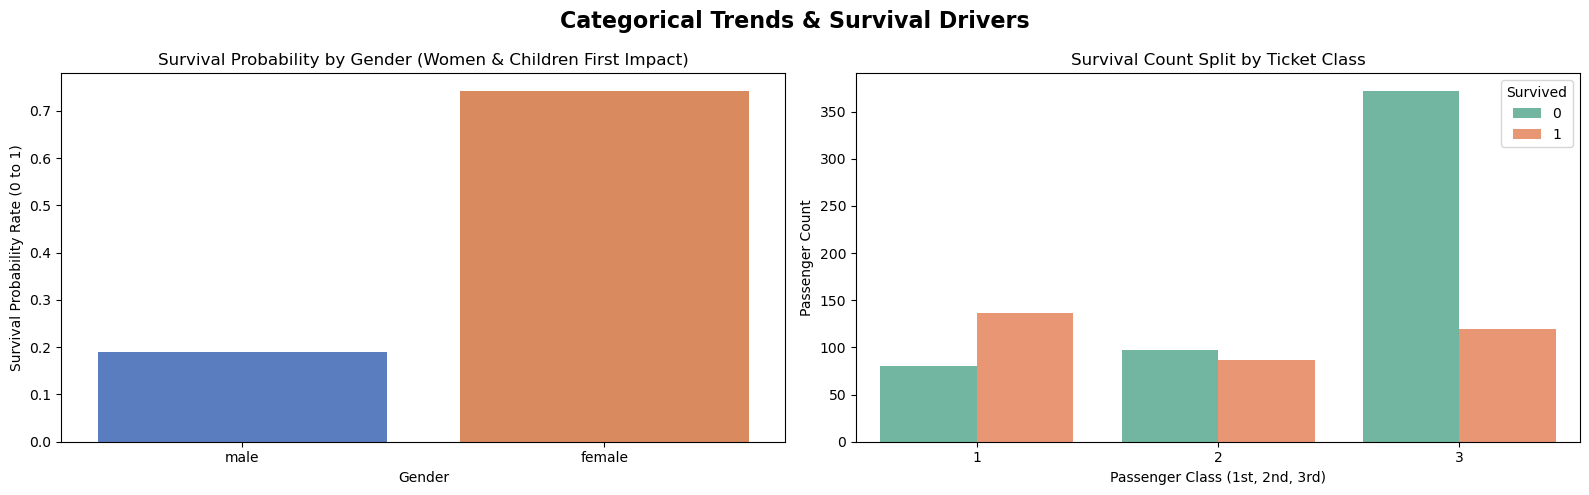

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
fig.suptitle('Categorical Trends & Survival Drivers', fontsize=16, fontweight='bold')

# Plot 1: Survival Rate by Gender (Inference-level visualization)
sns.barplot(x='Sex', y='Survived', data=df, palette='muted', errorbar=None, ax=axes[0])
axes[0].set_title('Survival Probability by Gender (Women & Children First Impact)')
axes[0].set_ylabel('Survival Probability Rate (0 to 1)')
axes[0].set_xlabel('Gender')

# Plot 2: Survival Count Split by Passenger Class (Socio-economic impact)
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Survival Count Split by Ticket Class')
axes[1].set_xlabel('Passenger Class (1st, 2nd, 3rd)')
axes[1].set_ylabel('Passenger Count')

plt.tight_layout()
plt.show()

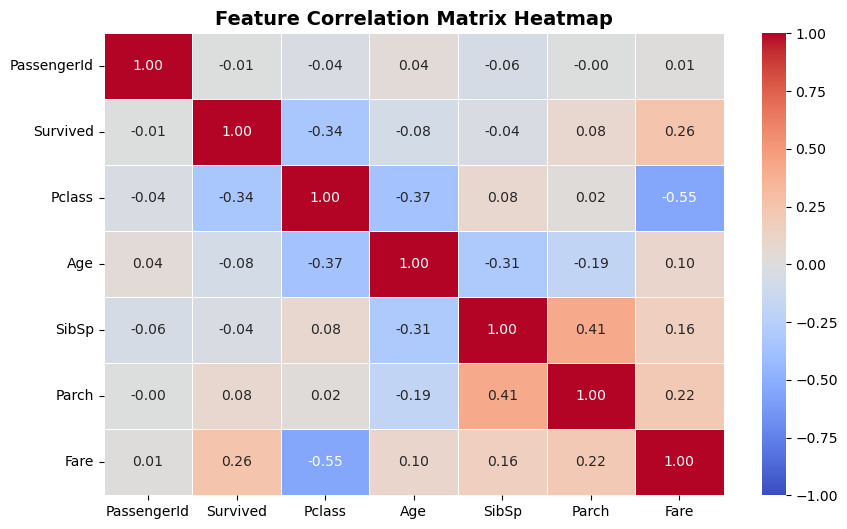

In [5]:
plt.figure(figsize=(10, 6))

# Filter out non-numeric columns to ensure correct mathematical calculation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Plot the heatmap matrix to analyze linear relationships and multicollinearity
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold')

plt.show()